<a href="https://colab.research.google.com/github/jessicasalazar/vision_computador/blob/main/Taller_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop # 4

* Implement a CNN or ViT model. It can be a model from a library (Keras) or a “vanilla” implementation of a CNN.
* Invent a pretext task
* Train on ImageNe


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers as L

In [ ]:
# Configuration
IMG_SIZE = 160  # size to resize
BATCH    = 128
EPOCHS_FROZEN   = 15
EPOCHS_UNFROZEN = 6
LR_FROZEN   = 3e-4
LR_UNFROZEN = 1e-4  # Learning ratio smaller to fine-tuning
SEED     = 1337
AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)

In [ ]:
# Dataset load (CIFAR-10)
(x_train, _), (x_val, _) = tf.keras.datasets.cifar10.load_data()

In [ ]:
# Preprocess
def preprocess(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    return x, y

def add_rotnet_label(x, _):
    k = tf.random.uniform((), 0, 4, dtype=tf.int32) # pretext task is random rotation k∈{0,1,2,3}
    x = tf.image.rot90(x, k)
    y = k  # the label is the discretized angle (0,1,2,3)
    return x, y

In [ ]:
# Pipelines tf.data
ds_train = tf.data.Dataset.from_tensor_slices((x_train, tf.zeros((x_train.shape[0],))))
ds_train = ds_train.shuffle(50000, seed=SEED)
ds_train = ds_train.map(preprocess, num_parallel_calls=AUTOTUNE)
ds_train = ds_train.map(add_rotnet_label, num_parallel_calls=AUTOTUNE)
ds_train = ds_train.batch(BATCH).prefetch(AUTOTUNE)

ds_val = tf.data.Dataset.from_tensor_slices((x_val, tf.zeros((x_val.shape[0],))))
ds_val = ds_val.map(preprocess, num_parallel_calls=AUTOTUNE)
ds_val = ds_val.map(add_rotnet_label, num_parallel_calls=AUTOTUNE)
ds_val = ds_val.batch(BATCH).prefetch(AUTOTUNE)

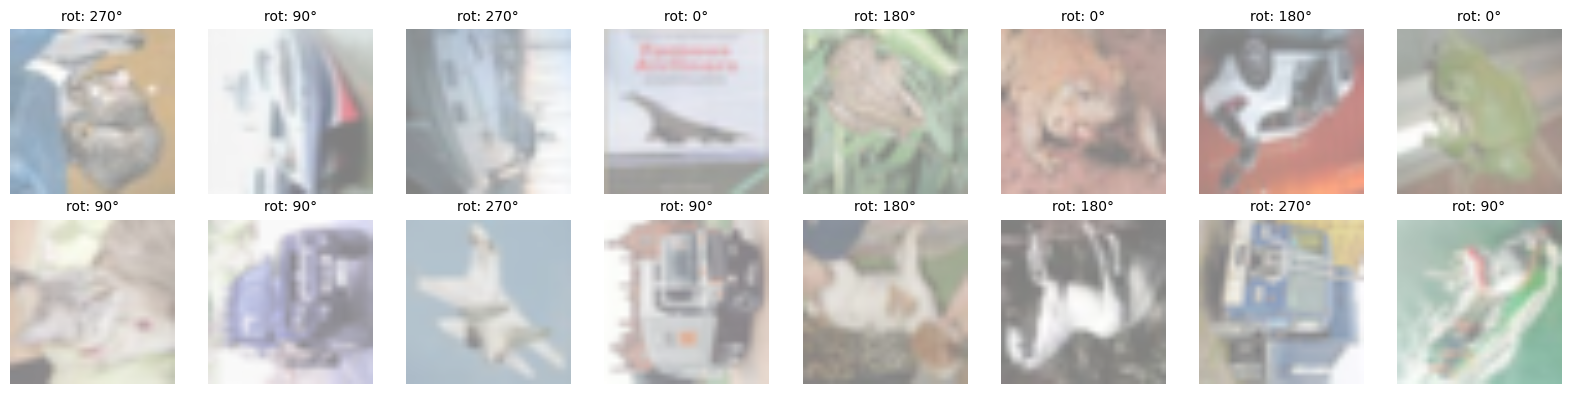

In [ ]:
# Visualizations of images with label and rotation angle
import matplotlib.pyplot as plt

N = 16
COLS = 8
DEG = ['0°','90°','180°','270°']

# We use a batch of validation dataset
for batch_imgs, batch_labels in ds_val.take(1):
    imgs = batch_imgs.numpy()
    labels = batch_labels.numpy()

    # Our pipeline use preprocess_input of MobileNetV2
    imgs = (imgs + 1.0) / 2.0
    imgs = imgs.clip(0, 1)

    # We set up the grid.
    rows = (N + COLS - 1) // COLS
    plt.figure(figsize=(COLS * 2, rows * 2))

    for i in range(N):
        if i >= len(imgs):
            break
        plt.subplot(rows, COLS, i + 1)
        plt.imshow(imgs[i])
        plt.title(f"rot: {DEG[int(labels[i])]}",
                  fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Model: MobileNetV2 (ImageNet) + cabeza RotNet
inp = L.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling='avg'
)
base.trainable = False
x = base(inp, training=False)
x = L.Dense(128, activation='relu', name='embed')(x)
x = L.Dropout(0.2)(x)
out = L.Dense(4, activation='softmax')(x)
model = tf.keras.Model(inp, out)

In [ ]:
# Compilation (phase 1: frozen base)
model.compile(optimizer=tf.keras.optimizers.Adam(LR_FROZEN),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
# Training (phase 1)
history = model.fit(ds_train,
                    validation_data=ds_val,
                    epochs=EPOCHS_FROZEN,
                    verbose=1)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 157ms/step - accuracy: 0.4272 - loss: 1.2197 - val_accuracy: 0.5399 - val_loss: 0.9674
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 37s 76ms/step - accuracy: 0.5378 - loss: 0.9717 - val_accuracy: 0.5686 - val_loss: 0.9202
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 75ms/step - accuracy: 0.5583 - loss: 0.9201 - val_accuracy: 0.5702 - val_loss: 0.8904
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.5724 - loss: 0.8932 - val_accuracy: 0.5826 - val_loss: 0.8759
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.5848 - loss: 0.8757 - val_accuracy: 0.5976 - val_loss: 0.8578
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.5943 - loss: 0.8506 - val_accuracy: 0.5971 - val_loss: 0.8480
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.5999 - loss: 0.8442 - val_accuracy: 0.5991 - val_loss: 0.8364
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.6024 - loss: 0.8396 -

In [ ]:
# Fine-tuning: Unfreeze the final part of the base
base.trainable = True
n_total = len(base.layers)
freeze_until = n_total - 40
for i, layer in enumerate(base.layers):
    layer.trainable = (i >= freeze_until)

In [ ]:
# Recompile with a lower learning rate.
model.compile(optimizer=tf.keras.optimizers.Adam(LR_UNFROZEN),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Training (phase 1)
model.fit(ds_train,
          validation_data=ds_val,
          epochs=EPOCHS_UNFROZEN,
          verbose=1)

Epoch 1/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 70s 129ms/step - accuracy: 0.5763 - loss: 0.9365 - val_accuracy: 0.4028 - val_loss: 1.9950
Epoch 2/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.7381 - loss: 0.6166 - val_accuracy: 0.4555 - val_loss: 1.4377
Epoch 3/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - accuracy: 0.7965 - loss: 0.5072 - val_accuracy: 0.6444 - val_loss: 0.9365
Epoch 4/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 85ms/step - accuracy: 0.8316 - loss: 0.4331 - val_accuracy: 0.6890 - val_loss: 0.8965
Epoch 5/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.8496 - loss: 0.3868 - val_accuracy: 0.7095 - val_loss: 0.7838
Epoch 6/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.8638 - loss: 0.3569 - val_accuracy: 0.6441 - val_loss: 1.1208


In [ ]:
# Evaluation
val_loss, val_acc = model.evaluate(ds_val, verbose=0)
print(f"Accuracy de rotación (val): {val_acc:.4f}")

Accuracy de rotación (val): 0.6444


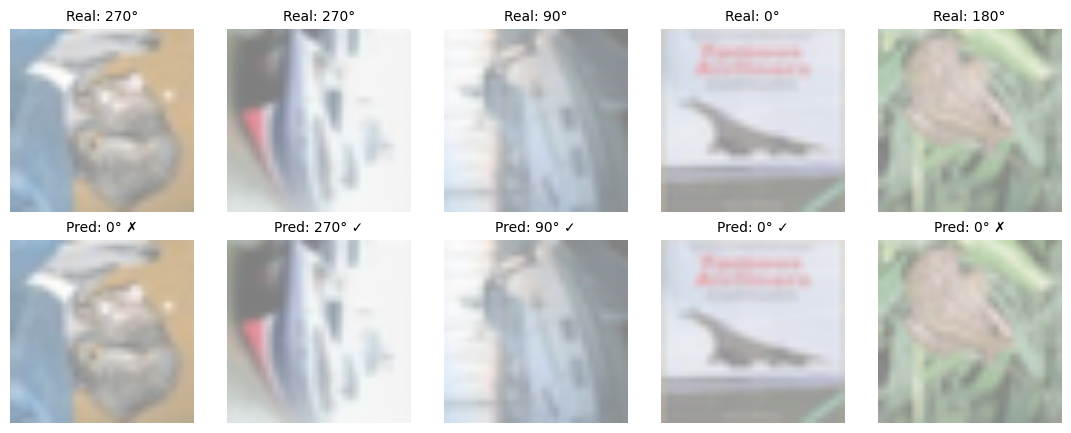

Guardado 'rotnet_5_pares.png'


<Figure size 640x480 with 0 Axes>

In [ ]:
# Show 5 pairs: (row 1) REAL label, (row 2) PREDICTED label.

import numpy as np
import matplotlib.pyplot as plt

DEG = ['0°','90°','180°','270°']
N = 5

# Batch to validation dataset
for batch_imgs, batch_labels in ds_val.take(1):
    imgs_tf = batch_imgs[:N]
    labels_tf = batch_labels[:N]

    logits = model.predict(imgs_tf, verbose=0)
    preds = np.argmax(logits, axis=1)

    # Tensor to numpy
    imgs = imgs_tf.numpy()
    imgs = (imgs + 1.0) / 2.0
    imgs = imgs.clip(0, 1)
    reals = labels_tf.numpy().astype(int)

    # We prepare a figure with 2 rows (real/pred) and N columns (N pairs).
    plt.figure(figsize=(N * 2.2, 2 * 2.2))

    for i in range(N):
        plt.subplot(2, N, i + 1)
        plt.imshow(imgs[i])
        plt.title(f"Real: {DEG[int(reals[i])]}",
                  fontsize=10)
        plt.axis('off')

    # PREDICTED
    for i in range(N):
        plt.subplot(2, N, N + i + 1)
        plt.imshow(imgs[i])
        ok = (preds[i] == reals[i])
        suf = "✓" if ok else "✗"
        plt.title(f"Pred: {DEG[int(preds[i])]} {suf}", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Save
    plt.savefig("rotnet_5_pares.png", dpi=150)
    print("Guardado 'rotnet_5_pares.png'")
